# Relatório de Análise de Importação de Vinhos

## 1. Introdução e Preparação dos Dados

Nesta análise, nosso objetivo foi entender melhor o mercado global de importação de vinhos, com um foco especial na posição do Brasil. Para isso, começamos organizando os dados brutos de importação.

Pegamos as informações anuais de diversos países e as transformamos em um formato mais fácil de analisar, criando duas medidas principais para cada ano e país: a **Quantidade total de vinho importado (em litros)** e o **Valor total gasto na importação (em Dólares Americanos - USD)**.

Após essa organização inicial, os primeiros gráficos que geramos nos permitiram identificar rapidamente quais são os países que mais importam vinho em termos de volume e valor, nos dando uma visão geral do cenário competitivo e do posicionamento inicial do Brasil.

In [ ]:
import pandas as pd
import numpy as np

# 1. Carregar a base de 2008 e a base principal
df_2008_raw = pd.read_csv('ImpVinhos2008.csv', sep=';')
importacao = pd.read_csv('importacao.csv', sep=';')

# 2. Preparar colunas de 2008 (Quantidade e Valor)
df_2008_subset = df_2008_raw[['País', '2008', '2008.1']].copy()

# 3. Injetar 2008 na base principal
# Usamos how='outer' para garantir que países de ambas as listas apareçam
importacao = pd.merge(importacao, df_2008_subset, on='País', how='outer')

# 4. Selecionar colunas (2008 a 2023)
colunas_quantidade = [col for col in importacao.columns if isinstance(col, str) and col.isdigit() and int(col) >= 2008 and int(col) <= 2023]
colunas_valor = [col for col in importacao.columns if isinstance(col, str) and '.1' in col and col.replace('.1', '').isdigit() and int(col.replace('.1', '')) >= 2008 and int(col.replace('.1', '')) <= 2023]

# 5. Converter para formato longo (Quantidade)
dados_quantidade = importacao.melt(
    id_vars=['País'],
    value_vars=colunas_quantidade,
    var_name='Ano',
    value_name='Quantidade_Litros'
)

# 6. Converter para formato longo (Valor)
dados_valor = importacao.melt(
    id_vars=['País'],
    value_vars=colunas_valor,
    var_name='Ano',
    value_name='Valor_USD'
)

# 7. Limpar nomes dos anos e unificar
dados_valor['Ano'] = dados_valor['Ano'].astype(str).str.replace('.1', '', regex=False)

df_final = dados_quantidade.merge(
    dados_valor,
    on=['País', 'Ano'],
    how='inner'
)

# 8. Ajustar tipos SEM preencher nulos
df_final['Ano'] = df_final['Ano'].astype(int)

# Convertemos para numérico, mas mantemos o NaN onde não houver valor
df_final['Quantidade_Litros'] = pd.to_numeric(df_final['Quantidade_Litros'], errors='coerce')
df_final['Valor_USD'] = pd.to_numeric(df_final['Valor_USD'], errors='coerce')

# Ordenação para conferência
df_final = df_final.sort_values(['País', 'Ano'])

print(df_final.head())

               País   Ano  Quantidade_Litros  Valor_USD
1095  Africa do Sul  2008           315380.0  1151699.0
0     Africa do Sul  2009           493093.0  1931449.0
73    Africa do Sul  2010           966276.0  3600658.0
146   Africa do Sul  2011           507509.0  2136394.0
219   Africa do Sul  2012           722327.0  3041449.0


In [ ]:
nome_arquivo = 'base_importacao_completa_2008_2023.csv'
df_final.to_csv(nome_arquivo, index=False, sep=';', encoding='utf-8-sig')

In [ ]:
# Libs para tratamento e analise dos dados

import pandas as pd
import numpy as np

In [ ]:
importacao = pd.read_csv('base_importacao_completa_2008_2023.csv', sep=';')
importacao.head()

,País,Ano,Quantidade_Litros,Valor_USD
0,Africa do Sul,2008,315380.0,1151699.0
1,Africa do Sul,2009,493093.0,1931449.0
2,Africa do Sul,2010,966276.0,3600658.0
3,Africa do Sul,2011,507509.0,2136394.0
4,Africa do Sul,2012,722327.0,3041449.0


Análise por País (ordenado por Valor Total - Top 5):


,País,Total_Quantidade_Litros,Total_Valor_USD
15,Chile,697504395.0,1.947327e+09
2,Argentina,279275355.0,9.154744e+08
55,Portugal,230013387.0,7.115984e+08
36,Itália,157026424.0,4.952758e+08
27,França,66066443.0,3.675778e+08


/tmp/ipython-input-3926046787.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax1 = sns.barplot(x='Total_Valor_USD', y='País', data=analise_por_pais_sorted.head(10), palette='viridis')


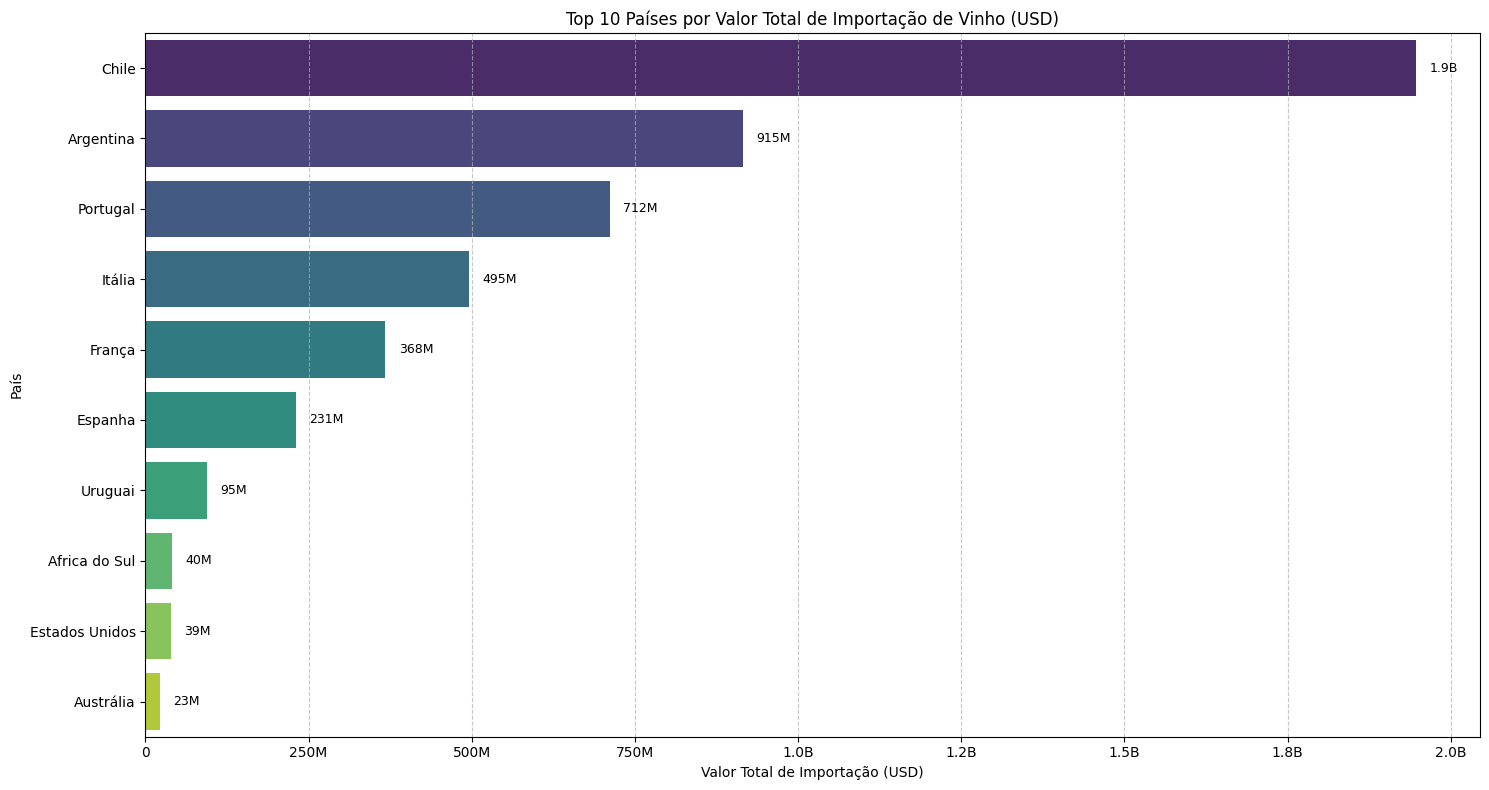

/tmp/ipython-input-3926046787.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax2 = sns.barplot(x='Total_Quantidade_Litros', y='País', data=analise_por_pais_sorted.sort_values(by='Total_Quantidade_Litros', ascending=False).head(10), palette='plasma')


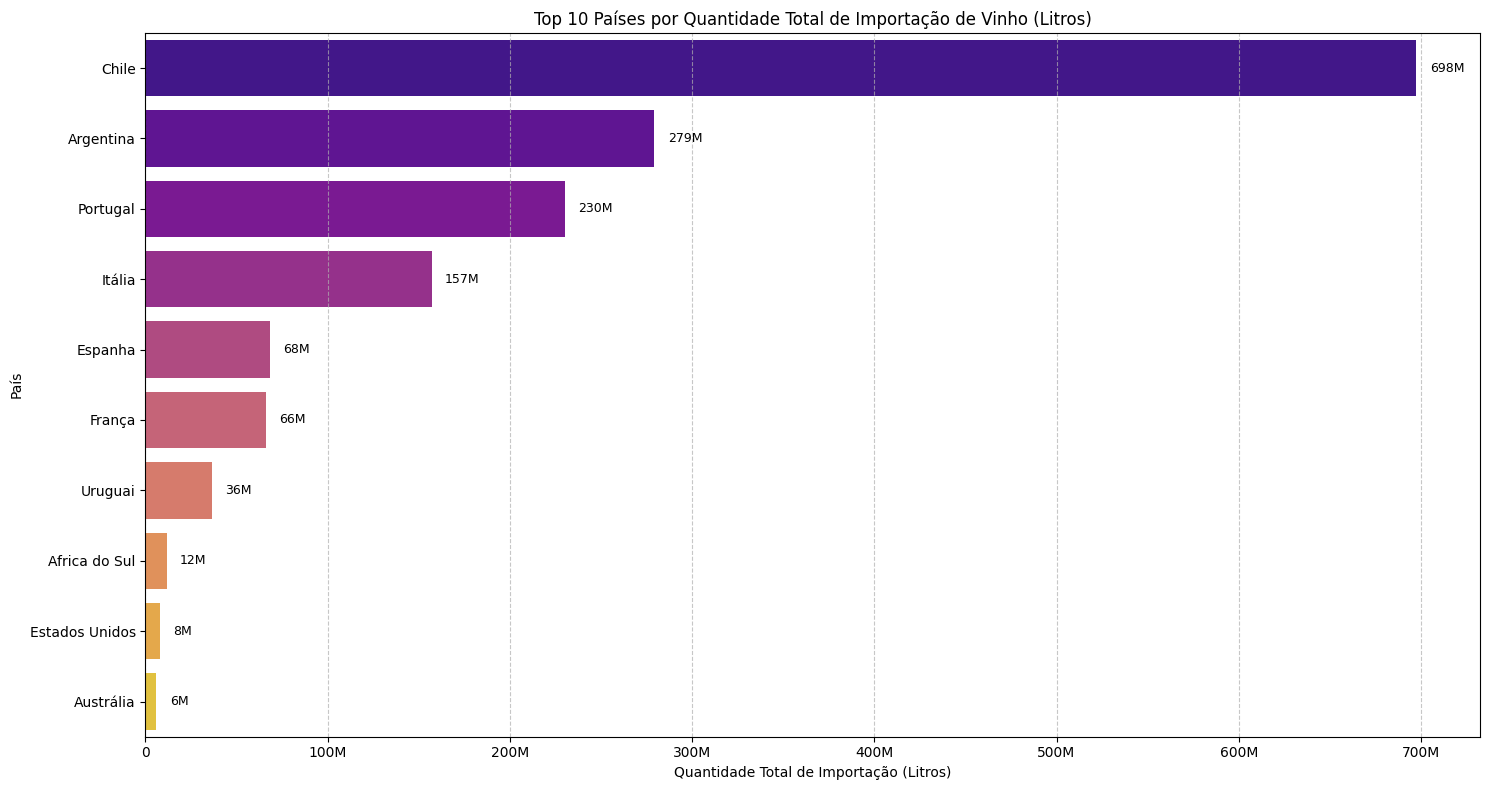

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter

# Agrupar por país e somar a quantidade e o valor
analise_por_pais = df_final.groupby('País').agg(
    Total_Quantidade_Litros=('Quantidade_Litros', 'sum'),
    Total_Valor_USD=('Valor_USD', 'sum')
).reset_index()

# Ordenar por valor total em ordem decrescente para visualização
analise_por_pais_sorted = analise_por_pais.sort_values(by='Total_Valor_USD', ascending=False)

# Exibir as primeiras linhas da análise para conferência
print('Análise por País (ordenado por Valor Total - Top 5):')
display(analise_por_pais_sorted.head())

# Função para formatar os ticks do eixo em milhões, bilhões, etc.
def large_number_formatter(x, pos):
    if x >= 1e9:
        return f'{x*1e-9:.1f}B' # Bilhões
    elif x >= 1e6:
        return f'{x*1e-6:.0f}M' # Milhões
    elif x >= 1e3:
        return f'{x*1e-3:.0f}K' # Milhares
    return f'{x:.0f}'

# Criar o gráfico de barras para Total_Valor_USD
plt.figure(figsize=(15, 8))
ax1 = sns.barplot(x='Total_Valor_USD', y='País', data=analise_por_pais_sorted.head(10), palette='viridis')
plt.title('Top 10 Países por Valor Total de Importação de Vinho (USD)')
plt.xlabel('Valor Total de Importação (USD)')
plt.ylabel('País')
plt.gca().xaxis.set_major_formatter(FuncFormatter(large_number_formatter)) # Aplicar formatador
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Adicionar os valores na frente das barras
for container in ax1.containers:
    for bar in container:
        x_val = bar.get_width()
        y_val = bar.get_y() + bar.get_height() / 2
        ax1.text(x_val + (ax1.get_xlim()[1] * 0.01), y_val, large_number_formatter(x_val, None), va='center', ha='left', fontsize=9)

plt.tight_layout()
plt.show()

# Criar o gráfico de barras para Total_Quantidade_Litros
plt.figure(figsize=(15, 8))
ax2 = sns.barplot(x='Total_Quantidade_Litros', y='País', data=analise_por_pais_sorted.sort_values(by='Total_Quantidade_Litros', ascending=False).head(10), palette='plasma')
plt.title('Top 10 Países por Quantidade Total de Importação de Vinho (Litros)')
plt.xlabel('Quantidade Total de Importação (Litros)')
plt.ylabel('País')
plt.gca().xaxis.set_major_formatter(FuncFormatter(large_number_formatter)) # Aplicar formatador
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Adicionar os valores na frente das barras
for container in ax2.containers:
    for bar in container:
        x_val = bar.get_width()
        y_val = bar.get_y() + bar.get_height() / 2
        ax2.text(x_val + (ax2.get_xlim()[1] * 0.01), y_val, large_number_formatter(x_val, None), va='center', ha='left', fontsize=9)

plt.tight_layout()
plt.show()

# Olhando para o Brasil

# 2. Análise Detalhada: A Posição do Brasil

Nesta etapa, focamos exclusivamente no Brasil para entender seu desempenho individual no mercado de importação de vinhos. Filtramos os dados para analisar a **quantidade de vinho importado (em litros)** e o **valor total gasto (em Dólares Americanos - USD)** pelo país, ano a ano.

Os gráficos gerados mostraram as flutuações nessas métricas ao longo dos anos, permitindo-nos observar tendências e períodos de maior ou menor atividade na importação de vinhos pelo Brasil. Além disso, para uma compreensão mais precisa do impacto econômico local, convertemos esses valores de USD para Reais (BRL), utilizando a cotação mais recente do dólar, o que nos deu uma visão atualizada e relevante do cenário financeiro da importação de vinhos no Brasil.

Análise do Brasil (Quantidade e Valor por Ano):


,País,Ano,Quantidade_Litros,Valor_USD
1105,Brasil,2008,309.0,1769.0
10,Brasil,2009,0.0,0.0
83,Brasil,2010,7.0,232.0
156,Brasil,2011,93.0,1164.0
229,Brasil,2012,1051.0,15016.0


/tmp/ipython-input-4243348911.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax_brasil_quant = sns.barplot(x='Ano', y='Quantidade_Litros', data=df_brasil, palette='viridis')


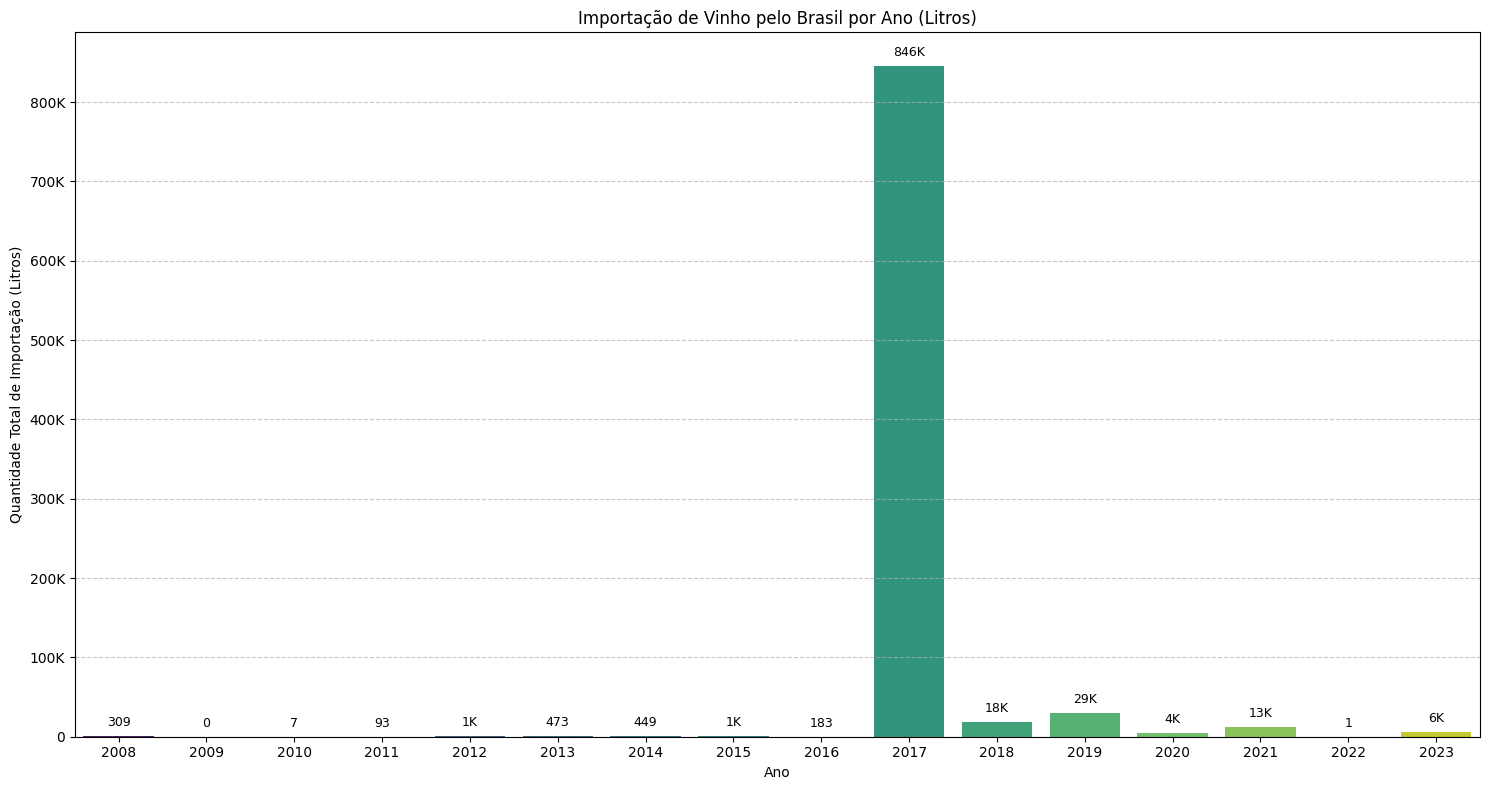

/tmp/ipython-input-4243348911.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax_brasil_valor = sns.barplot(x='Ano', y='Valor_USD', data=df_brasil, palette='plasma')


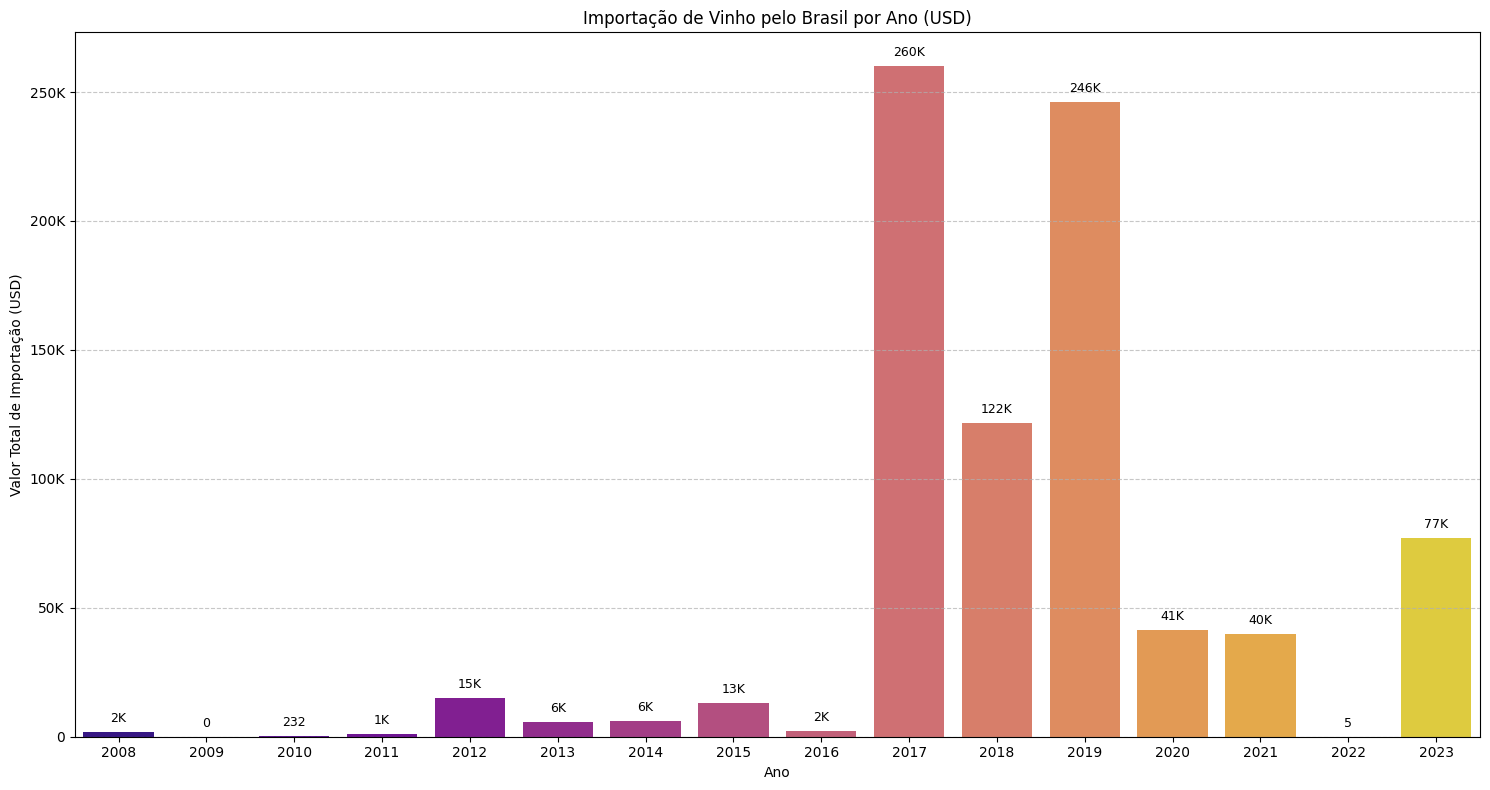

In [ ]:
df_brasil = df_final[df_final['País'] == 'Brasil'].copy()

print('Análise do Brasil (Quantidade e Valor por Ano):')
display(df_brasil.head())

# Criar o gráfico de barras para Quantidade_Litros do Brasil por Ano
plt.figure(figsize=(15, 8))
ax_brasil_quant = sns.barplot(x='Ano', y='Quantidade_Litros', data=df_brasil, palette='viridis')
plt.title('Importação de Vinho pelo Brasil por Ano (Litros)')
plt.xlabel('Ano')
plt.ylabel('Quantidade Total de Importação (Litros)')
plt.gca().yaxis.set_major_formatter(FuncFormatter(large_number_formatter))
plt.grid(axis='y', linestyle='--', alpha=0.7)

for container in ax_brasil_quant.containers:
    for bar in container:
        y_val = bar.get_height()
        x_val = bar.get_x() + bar.get_width() / 2
        ax_brasil_quant.text(x_val, y_val + (ax_brasil_quant.get_ylim()[1] * 0.01), large_number_formatter(y_val, None), ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

# Criar o gráfico de barras para Valor_USD do Brasil por Ano
plt.figure(figsize=(15, 8))
ax_brasil_valor = sns.barplot(x='Ano', y='Valor_USD', data=df_brasil, palette='plasma')
plt.title('Importação de Vinho pelo Brasil por Ano (USD)')
plt.xlabel('Ano')
plt.ylabel('Valor Total de Importação (USD)')
plt.gca().yaxis.set_major_formatter(FuncFormatter(large_number_formatter))
plt.grid(axis='y', linestyle='--', alpha=0.7)

for container in ax_brasil_valor.containers:
    for bar in container:
        y_val = bar.get_height()
        x_val = bar.get_x() + bar.get_width() / 2
        ax_brasil_valor.text(x_val, y_val + (ax_brasil_valor.get_ylim()[1] * 0.01), large_number_formatter(y_val, None), ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

# Importação de origem Brasil

Dados carregados com sucesso!
    Ano     Países  Valor US$ FOB
0  2008   Alemanha          12258
1  2008  Argentina        1787114
2  2008  Austrália           2623
3  2008     Brasil           2245
4  2008      Chile           1480


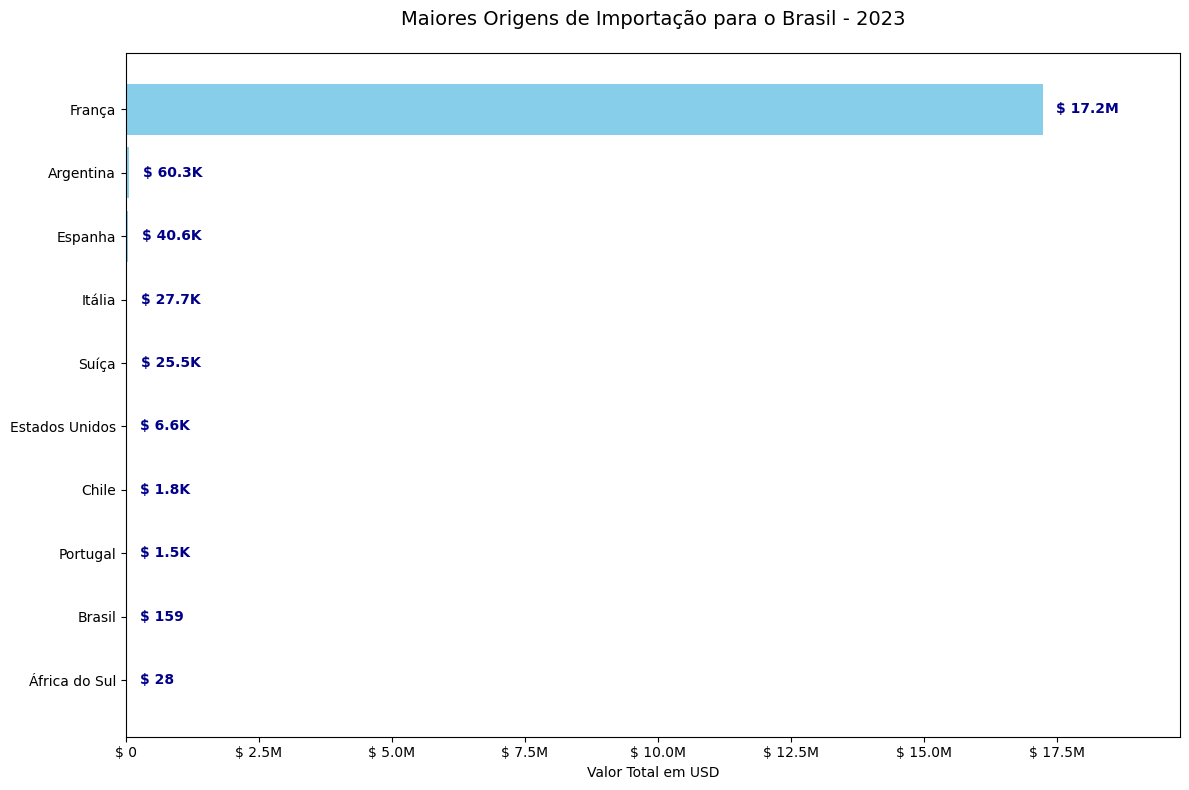

In [ ]:
# Carregar o novo arquivo
df_export = pd.read_csv('importacao_brasil.csv', sep=';')

# Limpar possíveis espaços ou aspas nos nomes das colunas e nos dados
df_export.columns = df_export.columns.str.replace('"', '').str.strip()
for col in df_export.columns:
    if df_export[col].dtype == 'object':
        df_export[col] = df_export[col].str.replace('"', '').str.strip()

# Converter Valor e Ano para numérico
df_export['Valor US$ FOB'] = pd.to_numeric(df_export['Valor US$ FOB'])
df_export['Ano'] = pd.to_numeric(df_export['Ano'])

# Agrupar por Ano e País (para somar diferentes tipos de vinho se houver)
df_resumo = df_export.groupby(['Ano', 'Países'])['Valor US$ FOB'].sum().reset_index()

print("Dados carregados com sucesso!")
print(df_resumo.head())
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# 1. Função de formatação para os rótulos (eixo e barras)
def format_milhoes_clean(x, pos=None):
    if x >= 1_000_000:
        return f'$ {x / 1_000_000:.1f}M'
    elif x >= 1_000:
        return f'$ {x / 1_000:.1f}K'
    return f'$ {x:.0f}'

# 2. Preparando os dados
top_10_2023 = df_resumo[df_resumo['Ano'] == 2023].nlargest(10, 'Valor US$ FOB')

# 3. Criando o gráfico
fig, ax = plt.subplots(figsize=(12, 8))
bars = ax.barh(top_10_2023['Países'], top_10_2023['Valor US$ FOB'], color='skyblue')

# --- AQUI ESTÁ A ALTERAÇÃO DO RODAPÉ (EIXO X) ---
ax.xaxis.set_major_formatter(FuncFormatter(format_milhoes_clean))

# 4. Adicionando os valores na frente das barras (usando a mesma lógica)
labels = [format_milhoes_clean(val) for val in top_10_2023['Valor US$ FOB']]
ax.bar_label(bars, labels=labels, padding=10, fontsize=10, fontweight='bold', color='darkblue')

# 5. Ajustes estéticos finais
ax.set_title('Maiores Origens de Importação para o Brasil - 2023', fontsize=14, pad=20)
ax.set_xlabel('Valor Total em USD')
ax.invert_yaxis()

# Aumentar margem para o texto não cortar
ax.set_xlim(0, top_10_2023['Valor US$ FOB'].max() * 1.15)

plt.tight_layout()
plt.show()

# Evolução anual

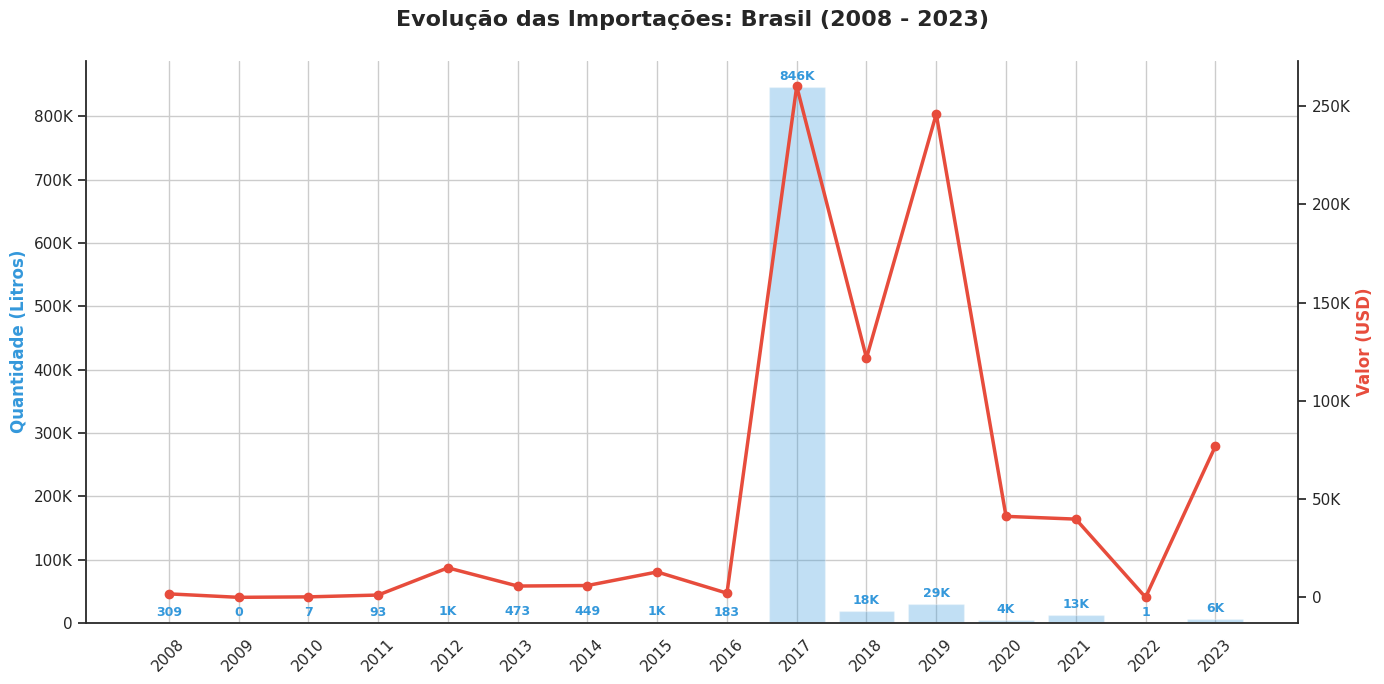

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

# 1. Função para formatar os números de forma "humana" (Ex: 1.5M, 200K)
def formatar_unidades(x, pos):
    if x >= 1_000_000:
        return f'{x*1e-6:1.1f}M'.replace('.', ',')
    elif x >= 1_000:
        return f'{x*1e-3:1.0f}K'.replace('.', ',')
    return f'{x:1.0f}'.replace('.', ',')

# 2. Filtrar dados do Brasil
df_brasil = df_final[df_final['País'] == 'Brasil'].sort_values('Ano')

# 3. Configurar o gráfico
fig, ax1 = plt.subplots(figsize=(14, 7))
sns.set_theme(style="white")

# --- Gráfico de Barras (Quantidade em Litros) ---
color_litros = '#3498db'
bars = ax1.bar(df_brasil['Ano'], df_brasil['Quantidade_Litros'], color=color_litros, alpha=0.3, label='Litros')
ax1.set_ylabel('Quantidade (Litros)', color=color_litros, fontsize=12, fontweight='bold')

# Aplicar formatação no eixo Y da esquerda
ax1.yaxis.set_major_formatter(ticker.FuncFormatter(formatar_unidades))

# Adicionar rótulos formatados em cima de cada barra
labels_litros = [formatar_unidades(val, None) for val in df_brasil['Quantidade_Litros']]
ax1.bar_label(bars, labels=labels_litros, padding=3, fontsize=9, color=color_litros, fontweight='bold')

# --- Gráfico de Linha (Valor em USD) ---
ax2 = ax1.twinx()
color_usd = '#e74c3c'
line = ax2.plot(df_brasil['Ano'], df_brasil['Valor_USD'], color=color_usd, marker='o', linewidth=2.5, label='Valor USD')
ax2.set_ylabel('Valor (USD)', color=color_usd, fontsize=12, fontweight='bold')

# Aplicar formatação no eixo Y da direita
ax2.yaxis.set_major_formatter(ticker.FuncFormatter(formatar_unidades))

# 4. Ajustes Finais
plt.title('Evolução das Importações: Brasil (2008 - 2023)', fontsize=16, fontweight='bold', pad=25)
ax1.set_xticks(df_brasil['Ano'])
ax1.tick_params(axis='x', rotation=45)

# Remover as bordas desnecessárias (spines)
ax1.spines['top'].set_visible(False)
ax2.spines['top'].set_visible(False)

fig.tight_layout()
plt.show()

# Prosecção para o ano de 2024

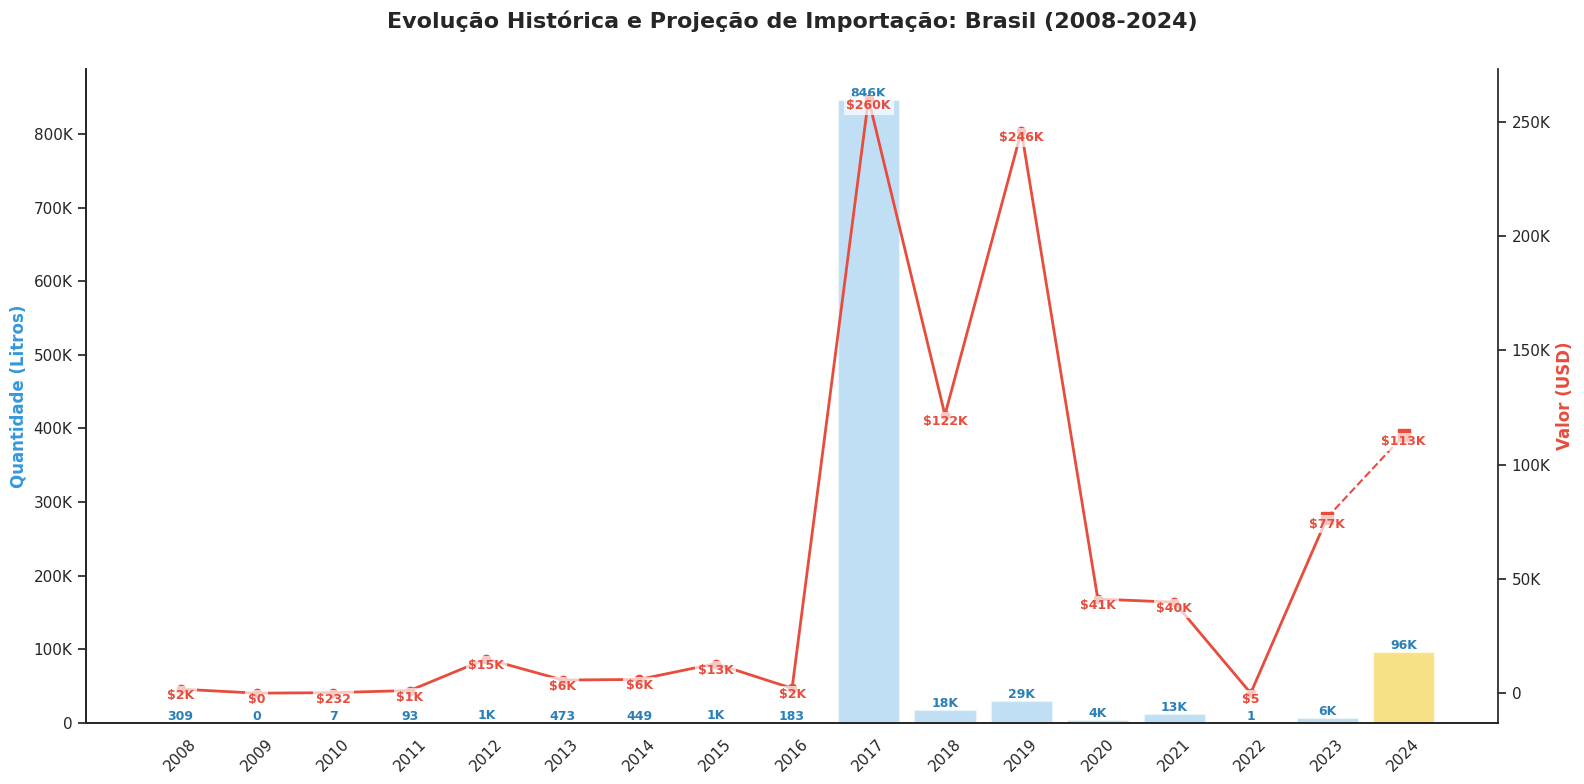

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from sklearn.linear_model import LinearRegression
import seaborn as sns
import numpy as np

# --- 1. PREPARAÇÃO DOS DADOS ---
# Filtramos o Brasil e garantimos que os dados estão em ordem cronológica
df_brasil = df_final[df_final['País'] == 'Brasil'].dropna(subset=['Quantidade_Litros', 'Valor_USD']).sort_values('Ano')

# Função de Regressão Linear para projetar 2024
def projetar_2024(df, coluna):
    X = df['Ano'].values.reshape(-1, 1)
    y = df[coluna].values
    modelo = LinearRegression().fit(X, y)
    return modelo.predict([[2024]])[0]

proj_qtd_2024 = projetar_2024(df_brasil, 'Quantidade_Litros')
proj_val_2024 = projetar_2024(df_brasil, 'Valor_USD')

# --- 2. FUNÇÃO DE FORMATAÇÃO ---
def formatar_unidades(x, pos=None):
    if abs(x) >= 1_000_000:
        return f'{x*1e-6:1.1f}M'.replace('.', ',')
    elif abs(x) >= 1_000:
        return f'{x*1e-3:1.0f}K'.replace('.', ',')
    return f'{x:1.0f}'.replace('.', ',')

# --- 3. CONSTRUÇÃO DO GRÁFICO ---
fig, ax1 = plt.subplots(figsize=(16, 8))
sns.set_theme(style="white")

anos_hist = df_brasil['Ano'].tolist()
qtds_hist = df_brasil['Quantidade_Litros'].tolist()
vals_hist = df_brasil['Valor_USD'].tolist()

# Eixo 1: Quantidade (Barras)
color_litros = '#3498db'
bars_hist = ax1.bar(anos_hist, qtds_hist, color=color_litros, alpha=0.3, label='Quantidade (Litros)')
bar_2024 = ax1.bar([2024], [proj_qtd_2024], color='#f1c40f', alpha=0.5, label='Projeção 2024')

# Eixo 2: Valor (Linha)
ax2 = ax1.twinx()
color_usd = '#e74c3c'
line_hist = ax2.plot(anos_hist, vals_hist, color=color_usd, marker='o', linewidth=2, label='Valor (USD)')
line_2024 = ax2.plot([anos_hist[-1], 2024], [vals_hist[-1], proj_val_2024],
                     color=color_usd, linestyle='--', marker='s', markersize=8)

# --- 4. APLICAÇÃO DOS RÓTULOS FORMATADOS ---

# Rótulos de Quantidade (nas barras)
for i, v in enumerate(qtds_hist + [proj_qtd_2024]):
    ano = (anos_hist + [2024])[i]
    ax1.text(ano, v, formatar_unidades(v), ha='center', va='bottom',
             fontsize=9, color='#2980b9', fontweight='bold')

# Rótulos de Valor (na linha)
for i, v in enumerate(vals_hist + [proj_val_2024]):
    ano = (anos_hist + [2024])[i]
    ax2.text(ano, v, f'${formatar_unidades(v)}', ha='center', va='top',
             fontsize=9, color=color_usd, fontweight='bold',
             bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=2))

# --- 5. AJUSTES FINAIS DE ESTÉTICA ---
ax1.yaxis.set_major_formatter(ticker.FuncFormatter(formatar_unidades))
ax2.yaxis.set_major_formatter(ticker.FuncFormatter(formatar_unidades))

ax1.set_xticks(anos_hist + [2024])
ax1.tick_params(axis='x', rotation=45)
ax1.set_ylabel('Quantidade (Litros)', color=color_litros, fontweight='bold')
ax2.set_ylabel('Valor (USD)', color=color_usd, fontweight='bold')

plt.title('Evolução Histórica e Projeção de Importação: Brasil (2008-2024)',
          fontsize=16, fontweight='bold', pad=30)

# Remover bordas superiores
sns.despine(ax=ax1, top=True)
ax2.spines['top'].set_visible(False)

plt.tight_layout()
plt.show()